# The Zero-Order-Hold Multiple Shooting trajectory leg

The Zero-Order-Hold Multiple Shooting (ZOH-MS) trajectory leg is implemented in `pykep` as {class}`pykep.leg.zoh_ms_py`. Unlike the single-shooting ZOH leg, it treats every mesh node as an explicit state and returns one continuity defect per segment. The parameter *cut* determines which segments are propagated forward from the initial node and which are propagated backward from the final node. This construction distributes continuity constraints across the mesh; it does not impose only one defect at the matching point.

Let the mesh contain $n$ segments, with states $\{\mathbf{x}_k\}_{k=0}^{n}$ at times $\{t_k\}_{k=0}^{n}$ and piecewise-constant controls $\{\mathbf{u}_k\}_{k=0}^{n-1}$. For the Keplerian example below, each control is
$$
\mathbf{u}_k = [T_k,\ i_{x,k},\ i_{y,k},\ i_{z,k}],
$$
where $T_k$ is the thrust magnitude and $(i_{x,k}, i_{y,k}, i_{z,k})$ specifies the thrust direction in the inertial frame. The generic leg itself assigns no physical meaning or bounds to the controls; those are determined by the supplied dynamics and the calling optimization problem.

For segment $k$, let $\Phi_k(\cdot;\mathbf{u}_k)$ denote propagation from $t_k$ to $t_{k+1}$ with control $\mathbf{u}_k$ held constant, and let $n_{\mathrm{fwd}}=\lfloor n\,\mathrm{cut}\rfloor$. The returned defect for each segment is
$$
\mathbf{d}_k =
\begin{cases}
\Phi_k(\mathbf{x}_k;\mathbf{u}_k)-\mathbf{x}_{k+1}, & 0 \le k < n_{\mathrm{fwd}}, \\
\mathbf{x}_k-\Phi_k^{-1}(\mathbf{x}_{k+1};\mathbf{u}_k), & n_{\mathrm{fwd}} \le k < n.
\end{cases}
$$
Feasibility requires $\mathbf{d}_k=\mathbf{0}$ for every $k=0,\ldots,n-1$. For an invertible flow, both branches have the same feasible set, although their residuals differ away from feasibility; consequently, `cut` can affect constraint scaling and Jacobian conditioning. `compute_defects()` returns the defects flattened in segment order, and the class provides their analytical sparse Jacobian with respect to the states, controls, and time grid.

We start with the required imports:

In [1]:
import pykep as pk
import heyoka as hy
import numpy as np
import pygmo as pg
from copy import deepcopy

%matplotlib inline

In [2]:
# Tolerances used in the numerical integration
# Lower tolerances are faster but less accurate (required tolerance depends on regime).
tol=1e-10
tol_var = 1e-6

# Instantiate ZOH Taylor integrators for Keplerian dynamics (provided by pykep).
# Contract with leg.zoh: state dimension = 7; first 4 parameters are controls;
# variational dynamics are first-order sensitivities w.r.t. state and controls.
ta_global = pk.ta.get_zoh_kep(tol)
ta_var_global = pk.ta.get_zoh_kep_var(tol_var)

# Non-dimensional units (the ZOH Taylor integrator in pykep expects MU=1).
L = pk.AU
MU = pk.MU_SUN
TIME = np.sqrt(L**3/MU)
V =  L/TIME
ACC = V/TIME
MASS = 1000
F = MASS*ACC

# 1 - Validate the Zero-Order-Hold multiple-shooting leg
We validate the analytical sparse Jacobians against dense finite-difference estimates.

This section also illustrates the standard construction workflow: define the mesh states, build controls and the time grid, instantiate the leg, then query defects and Jacobians.

We start with a helper function used for numerical differentiation:

In [3]:
# This assumes a copy of the leg, since it modifies one of its attributes.
def compute_defects_n(leg_mod, name, values):
    setattr(leg_mod, name, values)
    return leg_mod.compute_defects()

We now instantiate a representative leg by selecting the number of segments, the cut, the controls, and the time grid.

To obtain physically meaningful nodes, we construct them from a Lambert transfer between two Solar System planets. This choice is only for realism in the example; the method itself is general.

In [ ]:
# Starting consitions
pl0 = pk.planet(pk.udpla.jpl_lp("earth"))
epoch0 = pk.epoch(1345., pk.epoch.julian_type.MJD2000)
posvel0 = pl0.eph(epoch0)
# End conditions
pl1 = pk.planet(pk.udpla.jpl_lp("mars"))
epoch1 = pk.epoch(1745., pk.epoch.julian_type.MJD2000)
posvel1 = pl1.eph(epoch1)
# Assemble ballistic arc
tof = (epoch1.mjd2000-epoch0.mjd2000) * pk.DAY2SEC
l = pk.lambert_problem(r0 = posvel0[0], r1 = posvel1[0], tof = tof, mu = pl0.mu_central_body)   
# Produce ballistic arc states
N=10
r0, v0 = posvel0[0], l.v0[0]
tgrid = np.linspace(0, tof, N)
states = pk.propagate_lagrangian_grid([r0, v0], tgrid, pl0.mu_central_body)
# Flatten states and add mass and put all in non dimensional units
states_flattened_nd = []
for state in states:
    states_flattened_nd.extend([r/L for r in state[0]])
    states_flattened_nd.extend([v/V for v in state[1]])
    states_flattened_nd.extend([1.0])
tgrid_nd = tgrid / TIME
# Define ballistic controls
controls_nd = [0.2, 0.0,  1.0, 0.0] * (N-1)
# Construct leg (multiple-shooting)
leg = pk.leg.zoh_ms_py(states_flattened_nd, controls_nd, tgrid_nd, cut = 0.5, tas = [ta_global, ta_var_global])

We now compute and store the analytical sparse Jacobians of the defects.

In [5]:
defects = leg.compute_defects()
sparsities = leg.defects_grad_sparsity()
grads = leg.compute_defects_grad()

... and compare with dense numerical estimates. We use `pygmo` finite differences as a consistency check, sampling the dense Jacobian at the analytical sparsity indices.

In [6]:
for name, sp, grad in zip(["states", "controls", "tgrid"], sparsities, grads):
    leg_copy = deepcopy(leg)
    values = getattr(leg, name)
    grad_num = pg.estimate_gradient(
        lambda x: compute_defects_n(leg_copy, name, x), values
    ).reshape(len(defects), -1)
    print(name, np.linalg.norm(grad_num[sp[:, 0], sp[:, 1]] - grad))

states 1.06609026302e-07
controls 7.97833246186e-08
tgrid 2.17772901719e-08


The differences are small and consistent with finite-difference truncation/roundoff errors. In practice, analytical Jacobians are preferable for accuracy and efficiency.

We can now visualize the forward/backward trajectory segments, together with the planetary orbits.

In [8]:
def plot_leg(leg, N):
    fwd, bck, _ = leg.get_state_info(N)

    ax = pk.plot.make_3Daxis()
    for i, segment in enumerate(fwd):
        ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue')

    for j, segment in enumerate(bck):
        ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange')

    for i in range(len(leg.tgrid)-1):
        ax.scatter(leg.states[i*7], leg.states[i*7+1], leg.states[i*7+2], c='gray', marker='x')
    return ax


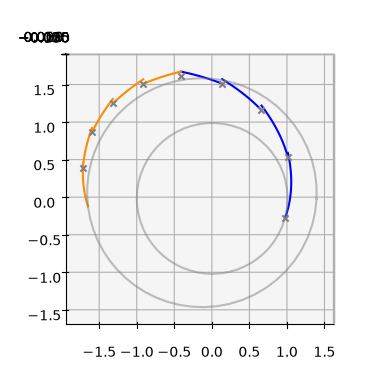

In [ ]:
ax = plot_leg(leg, 100)
pk.plot.add_planet_orbit(ax, pl0, units=pk.AU, color = 'gray', alpha=0.5)
pk.plot.add_planet_orbit(ax, pl1, units=pk.AU, color = 'gray', alpha=0.5)

ax.view_init(90,-90)
ax.set_aspect('equal')


A fundamental difference between a multiple shooting technique and, for example, the fwd-bck shooting of {class}`pykep.leg.zoh` (Sims-Flanagan style), is the presence of additional states between the initial and final: states that need to also be optimised and hence guessed. As to keep symmetry between the two ZOH implementations (fwd-bck and multiple shooting), `pykep` offers the initial guess function `pykep.leg.zoh_ms_py.initial_guess` which keeps the initial and final states as well as the controls, but re-defines the intermediate states automatically. Two guesses are available, one creates a feasible fwd and bck traectory, with a single mismatch at the intermediate states, while the other creates a purely ballistic guess for the intermediate states.

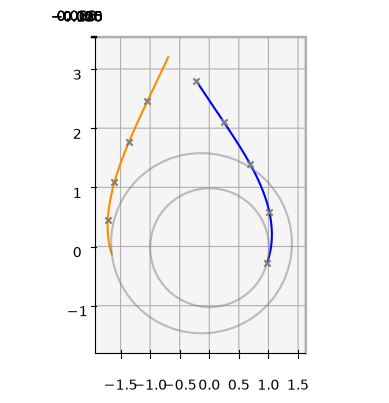

In [11]:
leg.set_initial_guess(ballistic=False)
ax = plot_leg(leg, 100)
pk.plot.add_planet_orbit(ax, pl0, units=pk.AU, color = 'gray', alpha=0.5)
pk.plot.add_planet_orbit(ax, pl1, units=pk.AU, color = 'gray', alpha=0.5)

ax.view_init(90,-90)
ax.set_aspect('equal')

# 2 - Use with a supplied generic propagator

The ZOH-MS leg can use any compatible Taylor-adaptive dynamics. Here we reuse `pykep`'s supplied CR3BP propagators and the Earth-Moon periodic Lyapunov orbit from the single-shooting notebook. The plot overlays the periodic reference orbit with the MS forward/backward segments and their boundary points.

In [36]:
cr3bp_ta = pk.ta.get_zoh_cr3bp(tol)
cr3bp_ta_var = pk.ta.get_zoh_cr3bp_var(tol_var)
cr3bp_mu = 0.01215058560962404
cr3bp_pars = [0.0, 0.0, 0.0, 0.0, 1.0, cr3bp_mu]
cr3bp_ta.pars[:] = cr3bp_pars
cr3bp_ta_var.pars[:] = cr3bp_pars

cr3bp_state0 = [5.5643551520142581e-02, 9.2420772211102929e-27, 1.3616512785913887e-31, 2.6173746491479341e-12, 5.2390814115699671e+00, 5.3268092625591314e-30, 1.0]
cr3bp_period = 6.301205688481844

cr3bp_ta.time = 0.0
cr3bp_ta.state[:] = cr3bp_state0
cr3bp_reference = cr3bp_ta.propagate_grid(
    np.linspace(0.0, cr3bp_period, 1000)
)[-1]

Select the same boundary epochs as in the single-shooting example and generate the multiple-shooting mesh by propagating the supplied CR3BP integrator.

In [42]:
cr3bp_t0, cr3bp_tf = -cr3bp_period / 3, cr3bp_period / 5
cr3bp_nseg = 10
cr3bp_tgrid = np.linspace(cr3bp_t0, cr3bp_tf, cr3bp_nseg + 1)

cr3bp_ta.pars[:] = cr3bp_pars
cr3bp_ta.time = 0.0
cr3bp_ta.state[:] = cr3bp_state0
cr3bp_ta.propagate_until(cr3bp_t0)
cr3bp_nodes = cr3bp_ta.propagate_grid(cr3bp_tgrid)[-1]
cr3bp_controls = [1.0, 1.0, 0.0, 0.0] * cr3bp_nseg

Construct the ZOH-MS leg from these nodes and overlay its propagated segments with the periodic reference orbit.

Reference period-closure error: 5.62993313045e-10
Start/end distance to plotted orbit: 3.1075658671e-11 5.61709821689e-06
Maximum position defect: 0.115630640918
Maximum full-state defect: 1.07738116409


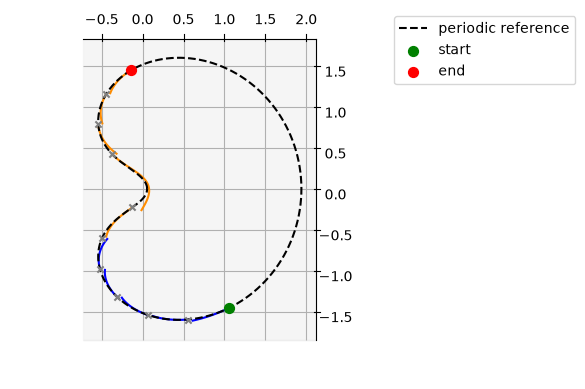

In [43]:
cr3bp_leg = pk.leg.zoh_ms_py(
    cr3bp_nodes.flatten().tolist(),
    cr3bp_controls,
    cr3bp_tgrid,
    cut=0.5,
    tas=[cr3bp_ta, cr3bp_ta_var],
)
ax = plot_leg(cr3bp_leg, 100)
ax.plot(
    cr3bp_reference[:, 0],
    cr3bp_reference[:, 1],
    cr3bp_reference[:, 2],
    c="black",
    linestyle="--",
    label="periodic reference",
)
ax.scatter(*cr3bp_nodes[0, :3], c="green", marker="o", s=50, label="start")
ax.scatter(*cr3bp_nodes[-1, :3], c="red", marker="o", s=50, label="end")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.view_init(90, -90)
ax.set_zticks([])
ax.set_aspect("equal")
cr3bp_defects = np.asarray(cr3bp_leg.compute_defects()).reshape(cr3bp_nseg, -1)
reference_position = cr3bp_reference[:, :3]
reference_segments = np.diff(reference_position, axis=0)
reference_lengths2 = np.sum(reference_segments**2, axis=1)

def distance_to_reference(point):
    offsets = point - reference_position[:-1]
    fractions = np.clip(
        np.sum(offsets * reference_segments, axis=1) / reference_lengths2, 0.0, 1.0
    )
    closest = reference_position[:-1] + fractions[:, None] * reference_segments
    return np.min(np.linalg.norm(point - closest, axis=1))

print("Reference period-closure error:", np.linalg.norm(reference_position[-1] - reference_position[0]))
print("Start/end distance to plotted orbit:", distance_to_reference(cr3bp_nodes[0, :3]), distance_to_reference(cr3bp_nodes[-1, :3]))
print("Maximum position defect:", np.max(np.linalg.norm(cr3bp_defects[:, :3], axis=1)))
print("Maximum full-state defect:", np.max(np.linalg.norm(cr3bp_defects, axis=1)))